# Model Explainability

Goals:
- Global feature importance (mean |SHAP|)
- SHAP beeswarm summary plot
- Local explanation for a single customer
- Demonstrate high-risk vs low-risk explanations

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

c:\Users\dipes\anaconda3\envs\risk-scoring-system\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load trained model and test data

In [2]:
from src.models.registry import load_artifact

model        = load_artifact('xgb_calibrated')
scaler       = load_artifact('scaler')
feature_names = load_artifact('feature_names')

print(f'Loaded model. Features: {len(feature_names)}')

2026-03-16 21:57:10 [INFO] src.models.registry: Artifact loaded <- C:\Users\dipes\Desktop\Projects\risk-scoring-system\artifacts\models\xgb_calibrated.joblib
2026-03-16 21:57:10 [INFO] src.models.registry: Artifact loaded <- C:\Users\dipes\Desktop\Projects\risk-scoring-system\artifacts\models\scaler.joblib
2026-03-16 21:57:10 [INFO] src.models.registry: Artifact loaded <- C:\Users\dipes\Desktop\Projects\risk-scoring-system\artifacts\models\feature_names.joblib
Loaded model. Features: 31


In [3]:
from src.ingestion.load_data import load_raw
from src.processing.preprocess import clean_raw, apply_scaler
from src.features.feature_store import add_derived_features
from src.processing.split import split_dataset, get_X_y

df_raw = load_raw()
df     = add_derived_features(clean_raw(df_raw))
_, _, df_test = split_dataset(df)
X_test_raw, y_test = get_X_y(df_test)
X_test = apply_scaler(X_test_raw, scaler)
print(f'Test set: {X_test.shape}')

2026-03-16 21:57:11 [INFO] src.ingestion.load_data: Loaded raw data: 30000 rows x 24 cols
2026-03-16 21:57:11 [DEBUG] src.processing.preprocess: Raw data cleaned: 30000 rows
2026-03-16 21:57:11 [DEBUG] src.features.feature_store: Derived features added. Total columns: 32
2026-03-16 21:57:11 [INFO] src.processing.split: Split -> train: 21000 | val: 4500 | test: 4500
2026-03-16 21:57:11 [INFO] src.processing.split:   train default rate: 22.12%
2026-03-16 21:57:11 [INFO] src.processing.split:   val default rate: 22.11%
2026-03-16 21:57:11 [INFO] src.processing.split:   test default rate: 22.11%
Test set: (4500, 31)


## Global feature importance

In [4]:
from src.explainability.shap_analysis import global_feature_importance

importance = global_feature_importance(model, X_test, feature_names)
print(importance.head(15).to_string(index=False))

2026-03-16 21:57:11 [INFO] src.explainability.shap_analysis: SHAP values computed for 500 samples × 31 features.
2026-03-16 21:57:11 [INFO] src.explainability.shap_analysis: Top 5 SHAP features:
          feature  mean_abs_shap
            PAY_0       0.325861
delinquency_count       0.300806
  max_delinquency       0.177505
         PAY_AMT2       0.154706
     util_ratio_1       0.146383
2026-03-16 21:57:11 [INFO] src.explainability.shap_analysis: Global SHAP importance saved -> C:\Users\dipes\Desktop\Projects\risk-scoring-system\artifacts\shap\global_importance.csv
          feature  mean_abs_shap
            PAY_0       0.325861
delinquency_count       0.300806
  max_delinquency       0.177505
         PAY_AMT2       0.154706
     util_ratio_1       0.146383
        BILL_AMT1       0.130642
         PAY_AMT3       0.102783
         PAY_AMT1       0.099740
       bill_trend       0.095566
        LIMIT_BAL       0.089227
   util_ratio_avg       0.086336
        BILL_AMT5       0.080

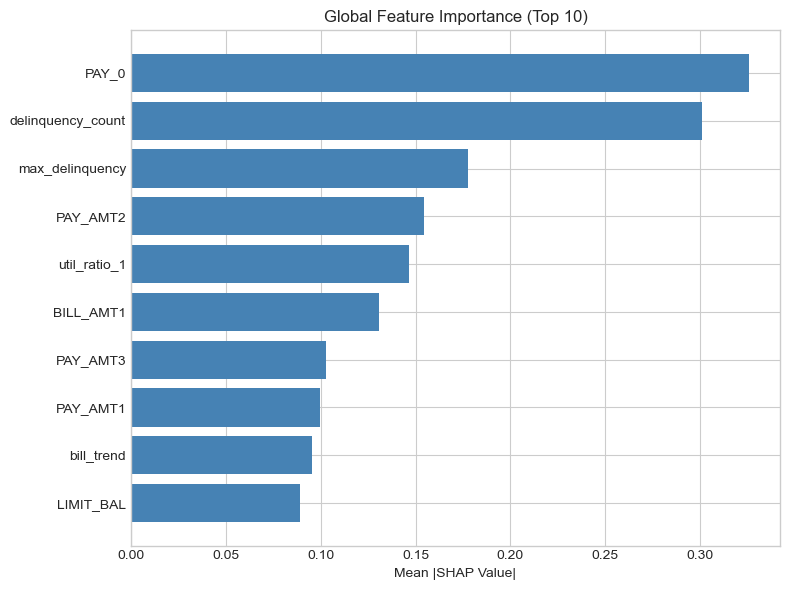

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
top10 = importance.head(10)
ax.barh(top10['feature'][::-1], top10['mean_abs_shap'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Global Feature Importance (Top 10)')
plt.tight_layout()
plt.savefig('../reports/figures/shap_global_importance.png', dpi=150)
plt.show()

## SHAP beeswarm summary

In [6]:
from src.explainability.shap_analysis import plot_shap_summary
from pathlib import Path

plot_shap_summary(model, X_test, feature_names,
                  save_path=Path('../reports/figures/shap_beeswarm.png'))

2026-03-16 21:57:11 [INFO] src.explainability.shap_analysis: SHAP values computed for 500 samples × 31 features.
2026-03-16 21:57:12 [INFO] src.explainability.shap_analysis: SHAP summary plot saved -> ..\reports\figures\shap_beeswarm.png


## Local explanation: single customer

In [7]:
from src.explainability.shap_analysis import explain_single

# Pick a high-risk customer
proba = model.predict_proba(X_test)[:, 1]
high_risk_idx = proba.argmax()
low_risk_idx  = proba.argmin()

for label, idx in [('HIGH RISK', high_risk_idx), ('LOW RISK', low_risk_idx)]:
    row = X_test.iloc[[idx]]
    drivers = explain_single(model, row, feature_names, top_n=5)
    p = proba[idx]
    print(f'\n=== {label} (score={round(p*100)}, prob={p:.2f}) ===')
    for d in drivers:
        sign = '+' if d['shap_value'] > 0 else '-'
        print(f"  {sign} {d['feature']}: {d['direction']} (SHAP={d['shap_value']:+.3f}, value={d['feature_value']:.2f})")


=== HIGH RISK (score=100, prob=1.00) ===
  + PAY_0: increases_risk (SHAP=+1.096, value=2.68)
  + delinquency_count: increases_risk (SHAP=+0.691, value=6.00)
  + max_delinquency: increases_risk (SHAP=+0.335, value=3.00)
  + BILL_AMT1: increases_risk (SHAP=+0.179, value=-0.66)
  + PAY_AMT3: increases_risk (SHAP=+0.163, value=-0.30)

=== LOW RISK (score=0, prob=0.00) ===
  - PAY_AMT1: decreases_risk (SHAP=-0.412, value=0.35)
  - PAY_AMT2: decreases_risk (SHAP=-0.333, value=0.35)
  - PAY_AMT3: decreases_risk (SHAP=-0.293, value=0.98)
  - BILL_AMT1: decreases_risk (SHAP=-0.251, value=0.35)
  - delinquency_count: decreases_risk (SHAP=-0.232, value=0.00)
